Data comes from here: https://data.cityofnewyork.us/Health/NYC-Restaurant-Inspection-Results/gv23-aida/about_data

In [30]:
import pandas as pd 
import geopandas as gpd

restaurants = pd.read_csv('restaurants.csv')

In [31]:
restaurants = restaurants.drop(columns=['VIOLATION DESCRIPTION', 'SCORE', 'GRADE'])

In [32]:
#restaurants.columns.to_list()
#restaurants['Address'] = (
#    restaurants['BUILDING'].astype(str) + " " + restaurants['STREET'].str.title() + ", " + restaurants["BORO"] + ", " + "NY" + " " + restaurants['ZIPCODE'].astype('Int64').astype(str)
#)

In [33]:
restaurants.shape

(294799, 7)

In [34]:
restaurants = restaurants.drop_duplicates()

In [35]:
restaurants = restaurants.reset_index(drop=True)

In [36]:
restaurants.head() 

,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION
0,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts
1,D.J. REYNOLDS,Manhattan,351,WEST 57 STREET,10019.0,2122452912,Irish
2,FRANK RIDOLFI,Manhattan,287,BLEECKER STREET,10014.0,NaN,NaN
3,"I. & L. DELICACIES,INC.",Manhattan,1500-2N,D AVE.,NaN,NaN,NaN
4,WILKEN'S FINE FOOD,Brooklyn,7114,AVENUE U,11234.0,7184443838,Sandwiches


In [37]:
restaurants = restaurants[[ 'DBA', 'BUILDING', 'STREET', 'BORO', 'ZIPCODE', 'PHONE', 'CUISINE DESCRIPTION']]

In [38]:
restaurants['ZIPCODE'] = restaurants['ZIPCODE'].astype('Int64')

In [39]:
restaurants.head()

,DBA,BUILDING,STREET,BORO,ZIPCODE,PHONE,CUISINE DESCRIPTION
0,MORRIS PARK BAKE SHOP,1007,MORRIS PARK AVENUE,Bronx,10462,7188924968,Bakery Products/Desserts
1,D.J. REYNOLDS,351,WEST 57 STREET,Manhattan,10019,2122452912,Irish
2,FRANK RIDOLFI,287,BLEECKER STREET,Manhattan,10014,NaN,NaN
3,"I. & L. DELICACIES,INC.",1500-2N,D AVE.,Manhattan,<NA>,NaN,NaN
4,WILKEN'S FINE FOOD,7114,AVENUE U,Brooklyn,11234,7184443838,Sandwiches


In [40]:
restaurants["CUISINE DESCRIPTION"].value_counts()

CUISINE DESCRIPTION
American         4808
Chinese          2264
Coffee/Tea       2212
Pizza            1613
Mexican          1116
                 ... 
Polynesian          2
Haute Cuisine       2
Basque              2
Chilean             2
Chimichurri         1
Name: count, Length: 90, dtype: int64

In [41]:
to_drop = ['Other', 'Juice, Smoothies, Fruit Salads', 'Bagels/Pretzels', 'Sandwiches/Salads/Mixed Buffet', 'Bottled Beverages', 'Soups/Salads/Sandwiches', 'Continental', 'Hotdogs/Pretzels', 'Not Listed/Not Applicable', 'Fruits/Vegetables', 'Nuts/Confectionary', 'Haute Cuisine']

In [42]:
restaurants = restaurants.dropna(subset=['CUISINE DESCRIPTION']).reset_index(drop=True)

In [43]:
restaurants = restaurants[~restaurants["CUISINE DESCRIPTION"].isin(to_drop)].reset_index(drop=True)

In [44]:
restaurants = restaurants.rename(columns={'CUISINE DESCRIPTION': 'CUISINE'})

In [45]:
restaurants['STATE'] = 'NY'
restaurants['STREET'] = restaurants['BUILDING'] + ' ' + restaurants['STREET']
restaurants = restaurants[[ 'DBA', 'BUILDING', 'STREET', 'BORO', 'STATE', 'ZIPCODE', 'PHONE', 'CUISINE']]
restaurants["STREET"] = restaurants["STREET"].str.replace(r"\s+", " ", regex=True).str.strip()

In [47]:
restaurants = restaurants.drop(columns=['BUILDING'])

In [48]:
restaurants.head()

,DBA,STREET,BORO,STATE,ZIPCODE,PHONE,CUISINE
0,MORRIS PARK BAKE SHOP,1007 MORRIS PARK AVENUE,Bronx,NY,10462,7188924968,Bakery Products/Desserts
1,D.J. REYNOLDS,351 WEST 57 STREET,Manhattan,NY,10019,2122452912,Irish
2,WILKEN'S FINE FOOD,7114 AVENUE U,Brooklyn,NY,11234,7184443838,Sandwiches
3,TASTE THE TROPICS ICE CREAM,1839 NOSTRAND AVENUE,Brooklyn,NY,11226,7188560821,Frozen Desserts
4,ASIA PLAZA CAFÉ,2300 SOUTHERN BOULEVARD,Bronx,NY,10460,7187411426,American


**Geocode all of these using the census geocoder batch API 

In [15]:
print(restaurants["CUISINE"].value_counts())
print(restaurants.shape)

CUISINE
American        4808
Chinese         2264
Coffee/Tea      2212
Pizza           1613
Mexican         1116
                ... 
Creole/Cajun       4
Polynesian         2
Basque             2
Chilean            2
Chimichurri        1
Name: count, Length: 78, dtype: int64
(25717, 8)


## Geocoding

In [54]:
restaurants['INDEX'] = restaurants.index

In [55]:
restaurants.head()

,DBA,STREET,BORO,STATE,ZIPCODE,PHONE,CUISINE,INDEX,ID
0,MORRIS PARK BAKE SHOP,1007 MORRIS PARK AVENUE,Bronx,NY,10462,7188924968,Bakery Products/Desserts,0,0
1,D.J. REYNOLDS,351 WEST 57 STREET,Manhattan,NY,10019,2122452912,Irish,1,1
2,WILKEN'S FINE FOOD,7114 AVENUE U,Brooklyn,NY,11234,7184443838,Sandwiches,2,2
3,TASTE THE TROPICS ICE CREAM,1839 NOSTRAND AVENUE,Brooklyn,NY,11226,7188560821,Frozen Desserts,3,3
4,ASIA PLAZA CAFÉ,2300 SOUTHERN BOULEVARD,Bronx,NY,10460,7187411426,American,4,4


In [58]:
import requests 
import io

URL = "https://geocoding.geo.census.gov/geocoder/locations/addressbatch"

def geocode_batch(chunk): 
    buf = io.StringIO()
    chunk[['INDEX', 'STREET', 'BORO', 'STATE', 'ZIPCODE']].to_csv(buf, index=False, header=False)
    buf.seek(0)
    r = requests.post(
        URL,
        files={"addressFile": ("addresses.csv", buf)},
        data={"benchmark": "Public_AR_Current"},
        timeout=300,
    )
    r.raise_for_status()
    cols = ["id", "input", "match", "match_type", "matched_addr", "coords", "tiger_id", "side"]
    return pd.read_csv(io.StringIO(r.text), names=cols, dtype={"id": int})

restaurants["id"] = range(len(restaurants))
results = pd.concat(
    [geocode_batch(restaurants.iloc[i:i + 10000]) for i in range(0, len(restaurants), 10000)]
)

results[['lon', 'lat']] = results['coords'].str.split(",", expand=True).astype(float)
restaurants = restaurants.merge(results[['id', 'lat', 'lon', 'match']], on='id', how='left')


In [61]:
results.head()

,id,input,match,match_type,matched_addr,coords,tiger_id,side,lon,lat
0,4970,"1323 AVENUE U, Brooklyn, NY, 11229",Match,Exact,"1323 AVE U, BROOKLYN, NY, 11229","-73.958019051838,40.598713126968",59091484.0,L,-73.958019,40.598713
1,3640,"1906 AVENUE U, Brooklyn, NY, 11229",Match,Exact,"1906 AVE U, BROOKLYN, NY, 11229","-73.95245728486,40.599209342735",59091580.0,R,-73.952457,40.599209
2,4971,"339 EAST 138 STREET, Bronx, NY, 10454",Match,Exact,"339 E 138TH ST, BRONX, NY, 10454","-73.924215738625,40.809727881167",80300386.0,L,-73.924216,40.809728
3,2306,"75 VICTORY BOULEVARD, Staten Island, NY, 10301",Match,Exact,"75 VICTORY BLVD, STATEN ISLAND, NY, 10301","-74.078586598249,40.63829760479",59879040.0,R,-74.078587,40.638298
4,3638,"150 EAST 52 STREET, Manhattan, NY, 10022",Match,Non_Exact,"150 E 52ND ST, NEW YORK, NY, 10022","-73.970671177632,40.757356091051",59657262.0,R,-73.970671,40.757356


In [63]:
restaurants = restaurants.merge(
    results[['id', 'lat', 'lon']],
    on='id',
    how='left'
)

In [71]:
restaurants = restaurants.drop(columns=['lat_y', 'lon_y'])
restaurants = restaurants.rename(columns={'lat_x': 'lat', 'lon_x': 'lon'})

In [72]:
restaurants.head()

,DBA,STREET,BORO,STATE,ZIPCODE,PHONE,CUISINE,INDEX,ID,id,lat,lon,match
0,MORRIS PARK BAKE SHOP,1007 MORRIS PARK AVENUE,Bronx,NY,10462,7188924968,Bakery Products/Desserts,0,0,0,40.848248,-73.856082,Match
1,D.J. REYNOLDS,351 WEST 57 STREET,Manhattan,NY,10019,2122452912,Irish,1,1,1,40.767526,-73.984638,Match
2,WILKEN'S FINE FOOD,7114 AVENUE U,Brooklyn,NY,11234,7184443838,Sandwiches,2,2,2,40.619860,-73.907290,Match
3,TASTE THE TROPICS ICE CREAM,1839 NOSTRAND AVENUE,Brooklyn,NY,11226,7188560821,Frozen Desserts,3,3,3,40.640893,-73.948434,Match
4,ASIA PLAZA CAFÉ,2300 SOUTHERN BOULEVARD,Bronx,NY,10460,7187411426,American,4,4,4,40.851618,-73.882087,Match


In [76]:
restaurants = restaurants.drop(columns=['INDEX', 'ID'])

In [77]:
restaurants.head()

,DBA,STREET,BORO,STATE,ZIPCODE,PHONE,CUISINE,id,lat,lon,match
0,MORRIS PARK BAKE SHOP,1007 MORRIS PARK AVENUE,Bronx,NY,10462,7188924968,Bakery Products/Desserts,0,40.848248,-73.856082,Match
1,D.J. REYNOLDS,351 WEST 57 STREET,Manhattan,NY,10019,2122452912,Irish,1,40.767526,-73.984638,Match
2,WILKEN'S FINE FOOD,7114 AVENUE U,Brooklyn,NY,11234,7184443838,Sandwiches,2,40.619860,-73.907290,Match
3,TASTE THE TROPICS ICE CREAM,1839 NOSTRAND AVENUE,Brooklyn,NY,11226,7188560821,Frozen Desserts,3,40.640893,-73.948434,Match
4,ASIA PLAZA CAFÉ,2300 SOUTHERN BOULEVARD,Bronx,NY,10460,7187411426,American,4,40.851618,-73.882087,Match


In [78]:
restaurants = restaurants.dropna(subset=['lat'])

In [82]:
restaurants.head()

,DBA,STREET,BORO,STATE,ZIPCODE,PHONE,CUISINE,id,lat,lon,match
0,MORRIS PARK BAKE SHOP,1007 MORRIS PARK AVENUE,Bronx,NY,10462,7188924968,Bakery Products/Desserts,0,40.848248,-73.856082,Match
1,D.J. REYNOLDS,351 WEST 57 STREET,Manhattan,NY,10019,2122452912,Irish,1,40.767526,-73.984638,Match
2,WILKEN'S FINE FOOD,7114 AVENUE U,Brooklyn,NY,11234,7184443838,Sandwiches,2,40.619860,-73.907290,Match
3,TASTE THE TROPICS ICE CREAM,1839 NOSTRAND AVENUE,Brooklyn,NY,11226,7188560821,Frozen Desserts,3,40.640893,-73.948434,Match
4,ASIA PLAZA CAFÉ,2300 SOUTHERN BOULEVARD,Bronx,NY,10460,7187411426,American,4,40.851618,-73.882087,Match


## Plotting

In [84]:
import geopandas as gpd
gdf = gpd.GeoDataFrame(
    restaurants,
    geometry = gpd.points_from_xy(restaurants['lon'], restaurants['lat']),
    crs='EPSG:4326'
)

<Axes: >

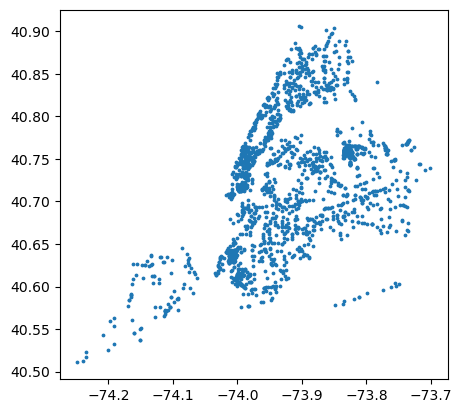

In [108]:
chinese = gdf.loc[gdf['CUISINE']=='Chinese']
chinese.plot(markersize=3)

In [109]:
gdf.to_file('restaurants.geojson', driver='GeoJSON')

In [113]:
gdf['CUISINE'].value_counts()

CUISINE
American          4402
Chinese           2231
Coffee/Tea        2095
Pizza             1552
Latin American    1089
                  ... 
Creole/Cajun         4
Polynesian           2
Basque               2
Chilean              2
Chimichurri          1
Name: count, Length: 78, dtype: int64